# LUNAR – analiza wyników

1. LUNAR Baseline — metryki + PR-curve + heatmapa hiperparametrów + Log-ROC
2. LUNAR vs Baselines — słupki/tabela + spadek jakości między zbiorami (CICIDS vs UNSW)
3. Ensembles & Fusion — porównanie strategii fuzji/ensemble + wykres radarowy (profil modeli)
4. Robustness — krzywe F1 vs noise/dropout + Zagregowany Indeks Odporności
5. Obliczenia i Złożoność — scatter F1 vs czas wnioskowania (trade-off)
6. Podsumowanie — wykres słupkowy rodzin + tabela zbiorcza z czasami + eksport do LaTeX

In [3]:
import json
import ast
from pathlib import Path
from math import pi

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

RESULTS_DIR = Path("../results")
AGG_DIR     = RESULTS_DIR / "aggregation"
FIG_DIR     = AGG_DIR / "notebook_figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 13,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'figure.titlesize': 14, 'figure.dpi': 110,
})
PALETTE = "Set2"

def save_fig(fig, name):
    png_path = FIG_DIR / f"{name}.png"
    pdf_path = FIG_DIR / f"{name}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Zapisano: {png_path.name} , {pdf_path.name}")
    return png_path, pdf_path

def load_raw_records(results_dir):
    records = []
    for path in sorted(Path(results_dir).glob("*.json")):
        try:
            with open(path, "r", encoding="utf-8") as f:
                records.append(json.load(f))
        except Exception as e:
            print("SKIP", path.name, e)
    return records

def get_param(hp_str, key):
    try:
        d = ast.literal_eval(hp_str)
        return d.get(key, np.nan)
    except Exception:
        return np.nan

In [4]:
df = pd.read_csv(AGG_DIR / "all_results_flat.csv")
df_std = df[df["threshold_variant"] == "standard"].copy()
METRIC_COLS = ["AUC_ROC", "AUC_PR", "Precision", "Recall", "F1"]

print(df.shape, "wierszy w all_results_flat.csv")
print("model_type:", sorted(df["model_type"].unique()))
print("dataset_name:", sorted(df["dataset_name"].unique()))

(882, 22) wierszy w all_results_flat.csv
model_type: ['Ensemble_with_LUNAR', 'Ensemble_without_LUNAR', 'Fusion_Level_Comparison', 'IsolationForest', 'LOF', 'LUNAR', 'LUNAR_Epochs_v2', 'LUNAR_Fusion_v2', 'LUNAR_Self_Ensemble', 'LUNAR_plus_BestBaseline', 'OneClassSVM', 'Robustness_Analysis']
dataset_name: ['CICIDS', 'UNSW_NB15']


## 1. LUNAR Baseline

,dataset_name,threshold_variant,AUC_ROC,AUC_PR,Precision,Recall,F1,runtime_train,runtime_inference
0,CICIDS,operational,0.867,0.734,0.427,0.932,0.586,192.6,7.60
1,CICIDS,operational,0.874,0.758,0.370,0.960,0.534,165.4,7.71
2,CICIDS,operational,0.868,0.738,0.430,0.932,0.588,316.3,9.89
3,CICIDS,recall_oriented,0.867,0.734,0.420,0.946,0.581,192.6,7.60
4,CICIDS,recall_oriented,0.874,0.758,0.317,0.964,0.477,165.4,7.71
5,CICIDS,recall_oriented,0.868,0.738,0.422,0.945,0.584,316.3,9.89
6,CICIDS,standard,0.867,0.734,0.656,0.688,0.672,192.6,7.60
7,CICIDS,standard,0.874,0.758,0.693,0.686,0.690,165.4,7.71
8,CICIDS,standard,0.868,0.738,0.662,0.687,0.674,316.3,9.89
9,UNSW_NB15,operational,0.884,0.928,0.647,0.923,0.761,417.9,13.58


Zapisano: 01a_lunar_pr_curve.png , 01a_lunar_pr_curve.pdf


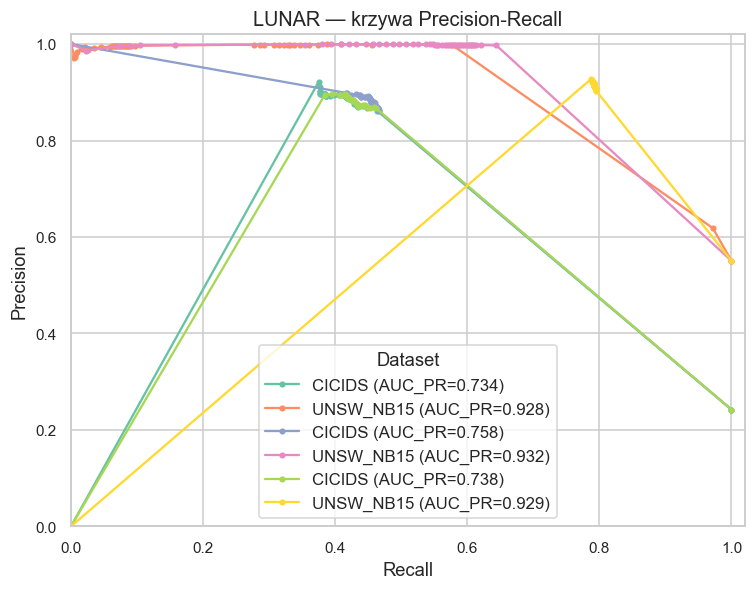

In [5]:
lunar_tbl = df[df["model_type"] == "LUNAR"][
    ["dataset_name", "threshold_variant", "AUC_ROC", "AUC_PR", "Precision", "Recall", "F1",
     "runtime_train", "runtime_inference"]
].sort_values(["dataset_name", "threshold_variant"]).reset_index(drop=True)

display(lunar_tbl.style.format({c: "{:.3f}" for c in METRIC_COLS} |
                                {"runtime_train": "{:.1f}", "runtime_inference": "{:.2f}"})
        .set_caption("LUNAR — metryki wg datasetu i wariantu progu"))
lunar_tbl.to_csv(FIG_DIR / "table_1_lunar_alone.csv", index=False)

records = load_raw_records(RESULTS_DIR)
lunar_records = [r for r in records if r.get("model_type") == "LUNAR" and r.get("pr_curve")]

fig, ax = plt.subplots(figsize=(7, 5.5))
colors = sns.color_palette(PALETTE, max(len(lunar_records), 3))
if lunar_records:
    for i, rec in enumerate(lunar_records):
        pr = pd.DataFrame(rec["pr_curve"])
        ax.plot(pr["recall"], pr["precision"], marker="o", markersize=3, color=colors[i],
                label=f'{rec["dataset_name"]} (AUC_PR={rec.get("AUC_PR", float("nan")):.3f})')
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("LUNAR — krzywa Precision-Recall")
    ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
    ax.legend(title="Dataset")
else:
    ax.text(0.5, 0.5, "Brak pr_curve w RESULTS_DIR", ha="center", va="center"); ax.axis("off")
fig.tight_layout()
save_fig(fig, "01a_lunar_pr_curve")
plt.show()

Zapisano: 01b_lunar_hyperparam_heatmap.png , 01b_lunar_hyperparam_heatmap.pdf


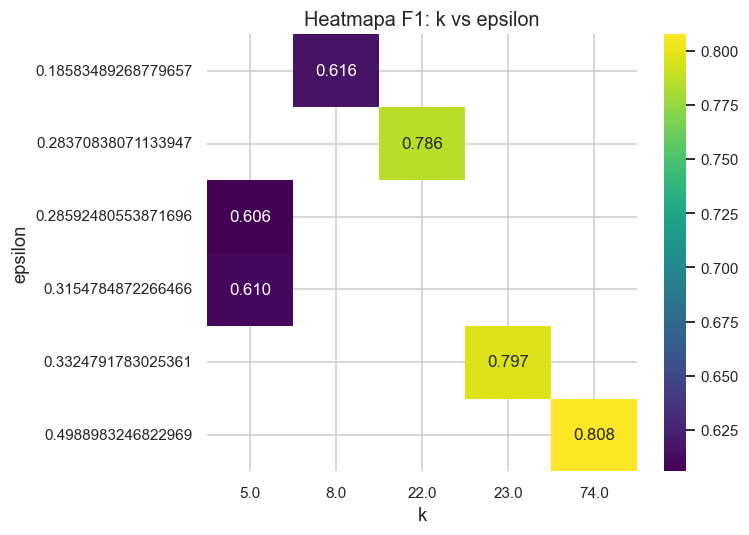

In [23]:
def extract_lunar_hp(row):
    try:
        d = ast.literal_eval(row["hyperparameters"])
    except Exception:
        return pd.Series({"k": np.nan, "epsilon": np.nan, "lr": np.nan})
    sub = d.get("lunar", d)  # w modelach złożonych parametry LUNAR są zagnieżdżone pod 'lunar'
    return pd.Series({"k": sub.get("k", np.nan), "epsilon": sub.get("epsilon", np.nan),
                       "lr": sub.get("lr", np.nan)})

lunar_family = df_std[df_std["model_type"].isin(
    ["LUNAR", "LUNAR_Self_Ensemble", "LUNAR_Fusion_v2", "Ensemble_with_LUNAR",
     "Fusion_Level_Comparison", "LUNAR_plus_BestBaseline", "Robustness_Analysis"])].copy()
hp = lunar_family.apply(extract_lunar_hp, axis=1)
lunar_family = pd.concat([lunar_family.reset_index(drop=True), hp.reset_index(drop=True)], axis=1)

HEATMAP_X, HEATMAP_Y, HEATMAP_METRIC = "k", "epsilon", "F1"
pivot = lunar_family.pivot_table(index=HEATMAP_Y, columns=HEATMAP_X, values=HEATMAP_METRIC, aggfunc="mean")

fig, ax = plt.subplots(figsize=(7, 5))
if pivot.shape[0] > 1 and pivot.shape[1] > 1:
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", ax=ax)
    ax.set_title(f"Heatmapa {HEATMAP_METRIC}: {HEATMAP_X} vs {HEATMAP_Y}")
else:
    k_by_dataset = lunar_family.groupby("dataset_name")["k"].first().to_dict()
    ax.axis("off")
    ax.text(0.5, 0.5,
            f"Za mało wariantów {HEATMAP_X}/{HEATMAP_Y} w obecnych danych do pełnej heatmapy.\n"
            f"W Twoich runach k jest ustalone per dataset: {k_by_dataset}.\n\n"
            f"Aby zobaczyć realną heatmapę k vs depth/epsilon, podłącz plik ze sweepem\n"
            f"hiperparametrów (np. Optuna trials CSV) w OPTUNA_TRIALS_CSV powyżej.",
            ha="center", va="center", wrap=True, fontsize=10)
fig.tight_layout()
save_fig(fig, "01b_lunar_hyperparam_heatmap")
plt.show()

Zapisano: 01c_lunar_log_roc.png , 01c_lunar_log_roc.pdf


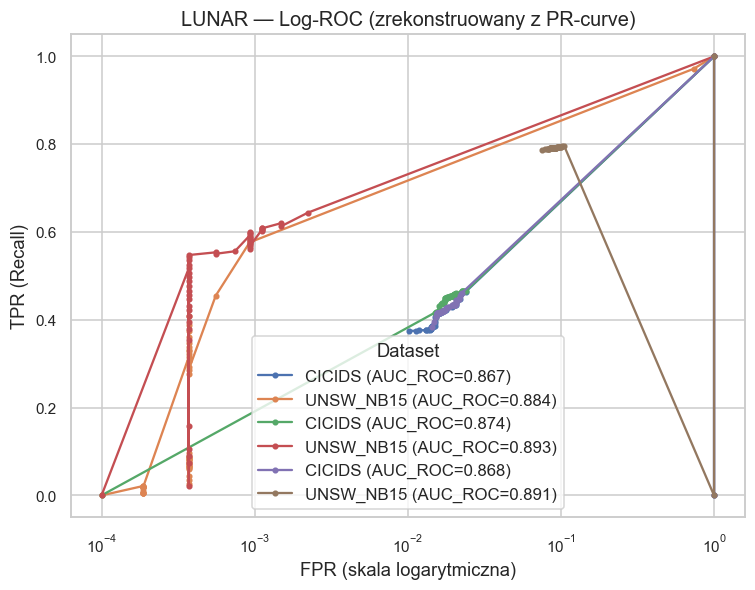

In [ ]:
def reconstruct_roc_from_pr(rec):
    pr = rec.get("pr_curve")
    cm = rec.get("ConfusionMatrix")
    if not pr or not cm:
        return None
    TN, FP0 = cm[0]
    FN, TP0 = cm[1]
    P, N = TP0 + FN, TN + FP0
    rows = []
    for pt in pr:
        prec, rec_ = pt["precision"], pt["recall"]
        TP = rec_ * P
        FP = TP * (1 / prec - 1) if prec > 0 else N
        FPR = FP / N if N > 0 else np.nan
        rows.append({"FPR": FPR, "TPR": rec_})
    return pd.DataFrame(rows).sort_values("FPR")

fig, ax = plt.subplots(figsize=(7, 5.5))
plotted = False
for rec in lunar_records:
    roc = reconstruct_roc_from_pr(rec)
    if roc is not None and not roc.empty:
        ax.plot(roc["FPR"].clip(lower=1e-4), roc["TPR"], marker="o", markersize=3,
                label=f'{rec["dataset_name"]} (AUC_ROC={rec.get("AUC_ROC", float("nan")):.3f})')
        plotted = True
if plotted:
    ax.set_xscale("log")
    ax.set_xlabel("FPR (skala logarytmiczna)")
    ax.set_ylabel("TPR (Recall)")
    ax.set_title("LUNAR — Log-ROC (zrekonstruowany z PR-curve)")
    ax.legend(title="Dataset")
else:
    ax.text(0.5, 0.5, "Brak pr_curve / ConfusionMatrix w wczytanych rekordach JSON.",
            ha="center", va="center"); ax.axis("off")
fig.tight_layout()
save_fig(fig, "01c_lunar_log_roc")
plt.show()

## 2. LUNAR vs Baselines

,dataset_name,model_type,AUC_ROC,AUC_PR,Precision,Recall,F1,runtime_train,runtime_inference
42,CICIDS,IsolationForest,0.829,0.615,0.481,0.695,0.568,0.6,1.19
336,CICIDS,IsolationForest,0.811,0.597,0.839,0.393,0.535,0.5,1.07
630,CICIDS,IsolationForest,0.817,0.613,0.816,0.415,0.550,0.5,0.88
44,CICIDS,LOF,0.857,0.575,0.586,0.845,0.692,1.6,3.28
338,CICIDS,LOF,0.845,0.554,0.587,0.715,0.645,10.7,20.17
632,CICIDS,LOF,0.842,0.499,0.577,0.739,0.648,9.7,19.08
46,CICIDS,LUNAR,0.867,0.734,0.656,0.688,0.672,192.6,7.60
340,CICIDS,LUNAR,0.874,0.758,0.693,0.686,0.690,165.4,7.71
634,CICIDS,LUNAR,0.868,0.738,0.662,0.687,0.674,316.3,9.89
184,CICIDS,OneClassSVM,0.768,0.623,0.243,1.000,0.391,0.8,1.67


Zapisano: 02a_lunar_vs_baselines_bar.png , 02a_lunar_vs_baselines_bar.pdf


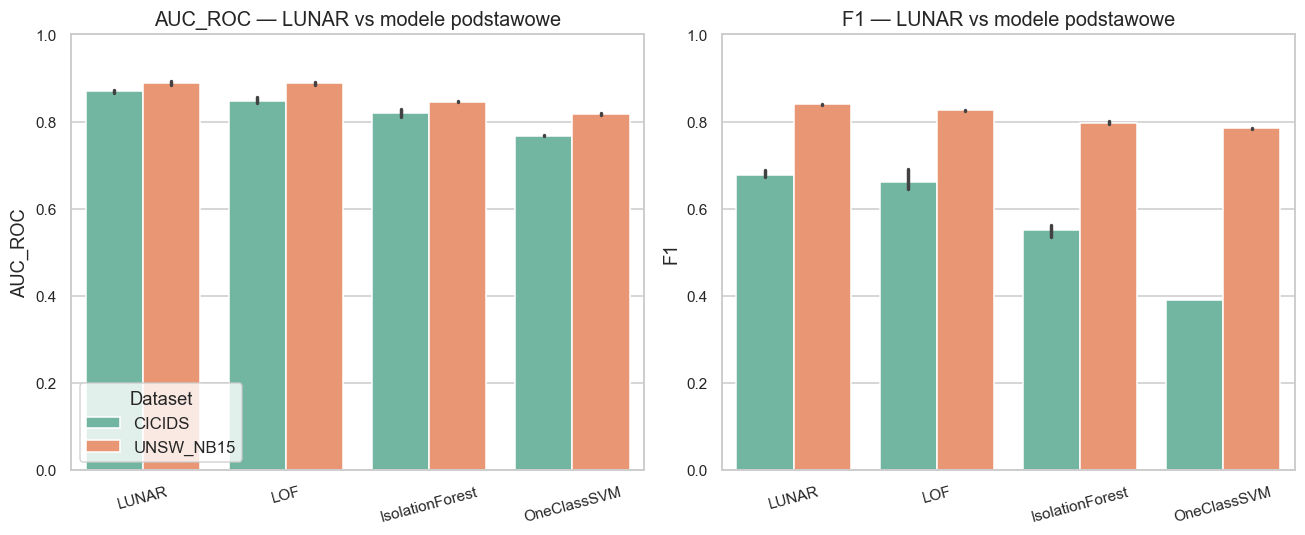

In [8]:
base_models = ["LUNAR", "LOF", "IsolationForest", "OneClassSVM"]
base_df = df_std[df_std["model_type"].isin(base_models)].copy()

base_tbl = base_df[["dataset_name", "model_type", "AUC_ROC", "AUC_PR", "Precision", "Recall", "F1",
                     "runtime_train", "runtime_inference"]].sort_values(["dataset_name", "model_type"])
display(base_tbl.style.format({c: "{:.3f}" for c in METRIC_COLS} |
                               {"runtime_train": "{:.1f}", "runtime_inference": "{:.2f}"})
        .set_caption("LUNAR vs modele podstawowe (próg standardowy)"))
base_tbl.to_csv(FIG_DIR / "table_2a_lunar_vs_baselines.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric in zip(axes, ["AUC_ROC", "F1"]):
    sns.barplot(data=base_df, x="model_type", y=metric, hue="dataset_name",
                order=base_models, palette=PALETTE, ax=ax)
    ax.set_title(f"{metric} — LUNAR vs modele podstawowe")
    ax.set_xlabel(""); ax.set_ylim(0, 1); ax.tick_params(axis="x", rotation=15)
axes[0].legend(title="Dataset"); axes[1].get_legend().remove()
fig.tight_layout()
save_fig(fig, "02a_lunar_vs_baselines_bar")
plt.show()

Zapisano: 02b_dataset_degradation.png , 02b_dataset_degradation.pdf


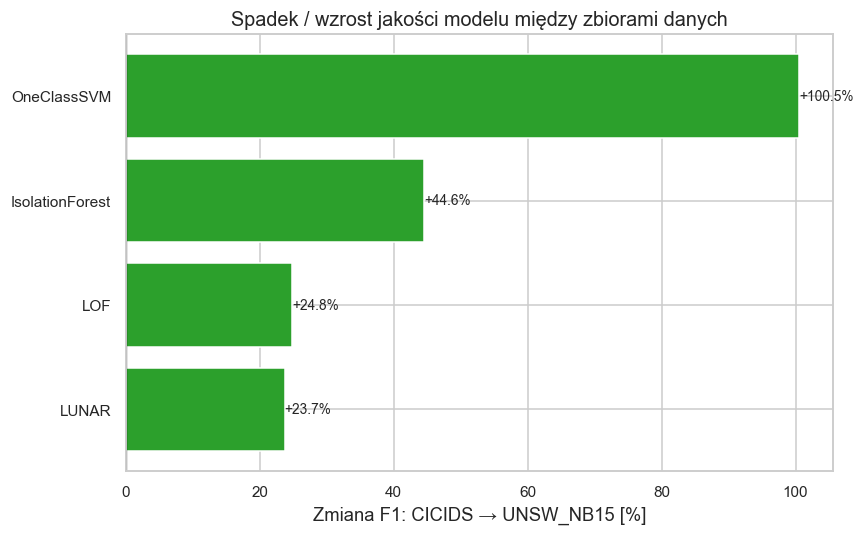

dataset_name,CICIDS,UNSW_NB15,delta_pct
model_type,,,
LUNAR,0.678,0.839,23.725
LOF,0.662,0.826,24.849
IsolationForest,0.551,0.797,44.553
OneClassSVM,0.391,0.785,100.519


In [ ]:
pivot_metric = base_df.pivot_table(index="model_type", columns="dataset_name", values="F1")
if {"CICIDS", "UNSW_NB15"}.issubset(pivot_metric.columns):
    pivot_metric["delta_pct"] = (pivot_metric["UNSW_NB15"] - pivot_metric["CICIDS"]) / pivot_metric["CICIDS"] * 100
    pivot_metric = pivot_metric.sort_values("delta_pct")

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ["#d62728" if v < 0 else "#2ca02c" for v in pivot_metric["delta_pct"]]
    ax.barh(pivot_metric.index, pivot_metric["delta_pct"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Zmiana F1: CICIDS → UNSW_NB15 [%]")
    ax.set_title("Spadek / wzrost jakości modelu między zbiorami danych")
    for y, v in enumerate(pivot_metric["delta_pct"]):
        ax.text(v, y, f"{v:+.1f}%", va="center", ha="left" if v >= 0 else "right", fontsize=9)
    fig.tight_layout()
    save_fig(fig, "02b_dataset_degradation")
    plt.show()

    display(pivot_metric.style.format("{:.3f}").set_caption("F1 na obu zbiorach + zmiana %"))
    pivot_metric.to_csv(FIG_DIR / "table_2b_dataset_degradation.csv")
else:
    print("Potrzebne oba datasety (CICIDS i UNSW_NB15) do wykresu spadku jakości.")

## 3. Ensembles & Fusion

,dataset_name,model_type,fusion_strategy,AUC_ROC,AUC_PR,Precision,Recall,F1
0,CICIDS,Ensemble_with_LUNAR,rank_mean,0.889,0.751,0.681,0.738,0.709
294,CICIDS,Ensemble_with_LUNAR,rank_mean,0.887,0.755,0.672,0.744,0.706
588,CICIDS,Ensemble_with_LUNAR,rank_mean,0.886,0.734,0.644,0.752,0.694
6,CICIDS,Ensemble_without_LUNAR,rank_mean,0.884,0.739,0.712,0.740,0.725
300,CICIDS,Ensemble_without_LUNAR,rank_mean,0.880,0.737,0.730,0.710,0.720
594,CICIDS,Ensemble_without_LUNAR,rank_mean,0.881,0.713,0.689,0.757,0.721
157,CICIDS,LUNAR_Self_Ensemble,bagging,0.866,0.734,0.653,0.689,0.671
451,CICIDS,LUNAR_Self_Ensemble,bagging,0.862,0.734,0.637,0.691,0.663
745,CICIDS,LUNAR_Self_Ensemble,bagging,0.866,0.736,0.655,0.689,0.671
163,CICIDS,LUNAR_Self_Ensemble,boosting,0.867,0.735,0.654,0.687,0.670


Zapisano: 03a_ensemble_with_vs_without_lunar.png , 03a_ensemble_with_vs_without_lunar.pdf


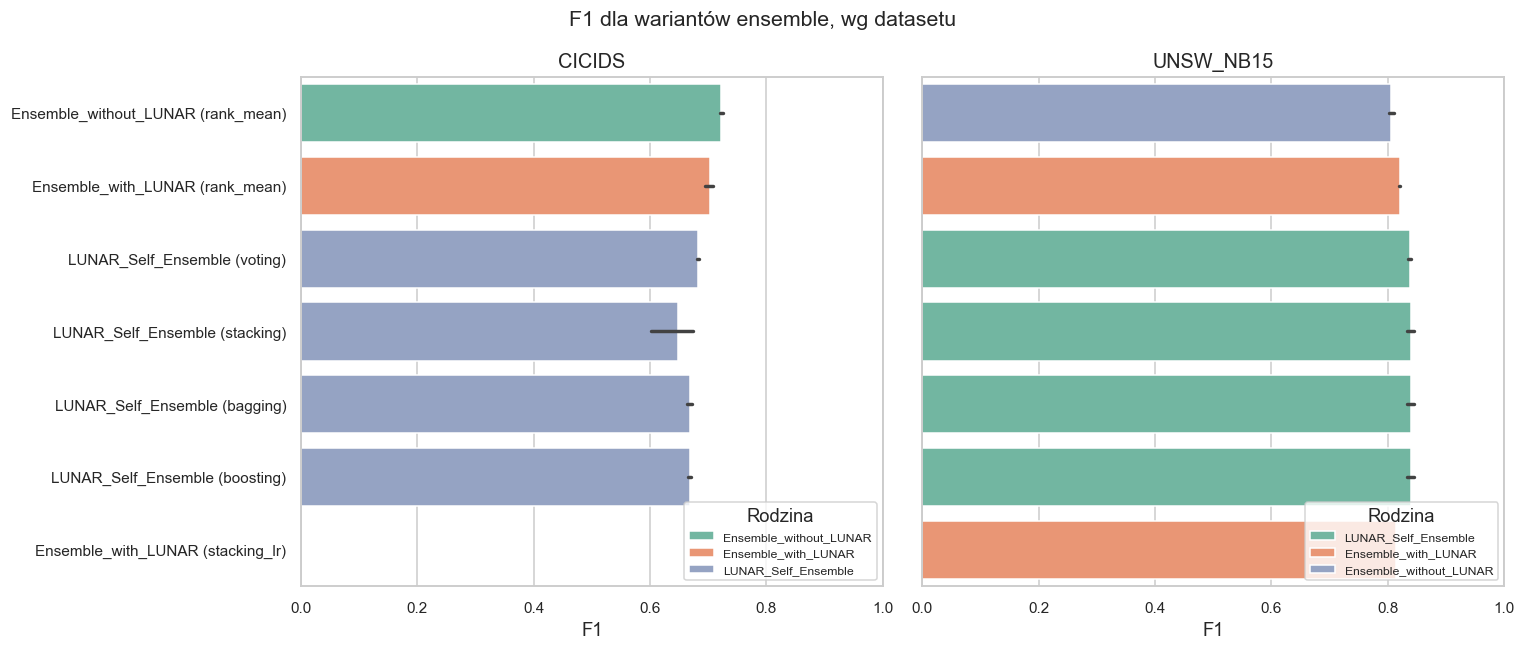

In [10]:
ens_models = ["Ensemble_with_LUNAR", "Ensemble_without_LUNAR", "LUNAR_Self_Ensemble"]
ens_df = df_std[df_std["model_type"].isin(ens_models)].copy()
ens_df["variant"] = ens_df["model_type"] + ens_df["fusion_strategy"].apply(lambda s: f" ({s})" if pd.notna(s) else "")

ens_tbl = ens_df[["dataset_name", "model_type", "fusion_strategy", "AUC_ROC", "AUC_PR",
                   "Precision", "Recall", "F1"]].sort_values(["dataset_name", "model_type", "fusion_strategy"])
display(ens_tbl.style.format({c: "{:.3f}" for c in METRIC_COLS})
        .set_caption("Ensemble z LUNAR vs bez LUNAR (+ Self-Ensemble)"))
ens_tbl.to_csv(FIG_DIR / "table_3a_ensemble.csv", index=False)

fig, axes = plt.subplots(1, len(df_std["dataset_name"].unique()), figsize=(14, 6), sharey=True)
for ax, (dset, sub) in zip(np.atleast_1d(axes), ens_df.groupby("dataset_name")):
    sub = sub.sort_values("F1", ascending=False)
    sns.barplot(data=sub, y="variant", x="F1", hue="model_type", dodge=False, palette=PALETTE, ax=ax)
    ax.set_title(dset); ax.set_xlim(0, 1); ax.set_xlabel("F1"); ax.set_ylabel("")
    if ax.get_legend():
        ax.legend(title="Rodzina", loc="lower right", fontsize=8)
fig.suptitle("F1 dla wariantów ensemble, wg datasetu")
fig.tight_layout()
save_fig(fig, "03a_ensemble_with_vs_without_lunar")
plt.show()

,dataset_name,fusion_strategy,AUC_ROC,AUC_PR,Precision,Recall,F1
12,CICIDS,decision_level_AND,0.795,0.580,0.755,0.658,0.703
306,CICIDS,decision_level_AND,0.734,0.501,0.728,0.532,0.615
600,CICIDS,decision_level_AND,0.724,0.479,0.698,0.519,0.595
18,CICIDS,decision_level_OR,0.819,0.503,0.540,0.876,0.668
312,CICIDS,decision_level_OR,0.837,0.543,0.588,0.869,0.701
606,CICIDS,decision_level_OR,0.847,0.545,0.576,0.907,0.705
24,CICIDS,feature_level,0.960,0.880,0.794,0.853,0.822
318,CICIDS,feature_level,0.961,0.884,0.795,0.840,0.817
612,CICIDS,feature_level,0.960,0.882,0.793,0.834,0.813
30,CICIDS,lunar_self_ensemble,0.792,0.546,0.680,0.683,0.681


Zapisano: 03b_fusion_levels_bar.png , 03b_fusion_levels_bar.pdf


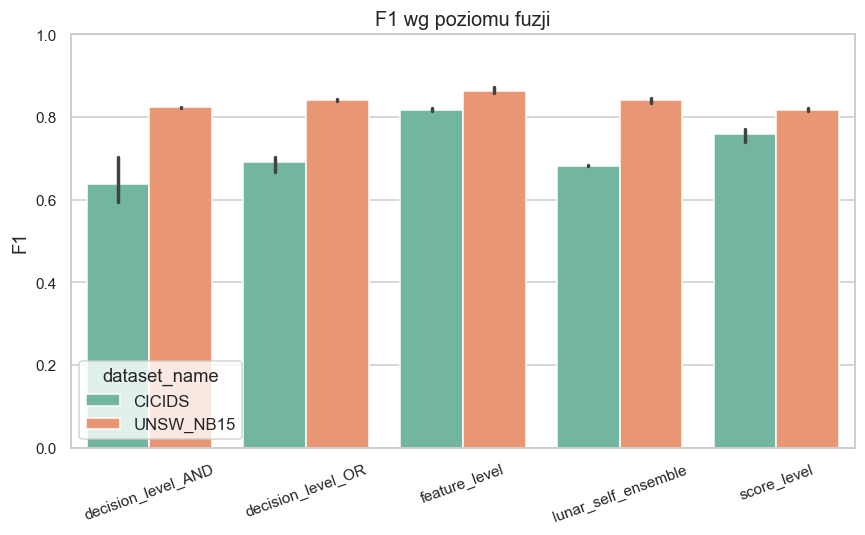

Zapisano: 03c_fusion_sensitivity_curves.png , 03c_fusion_sensitivity_curves.pdf


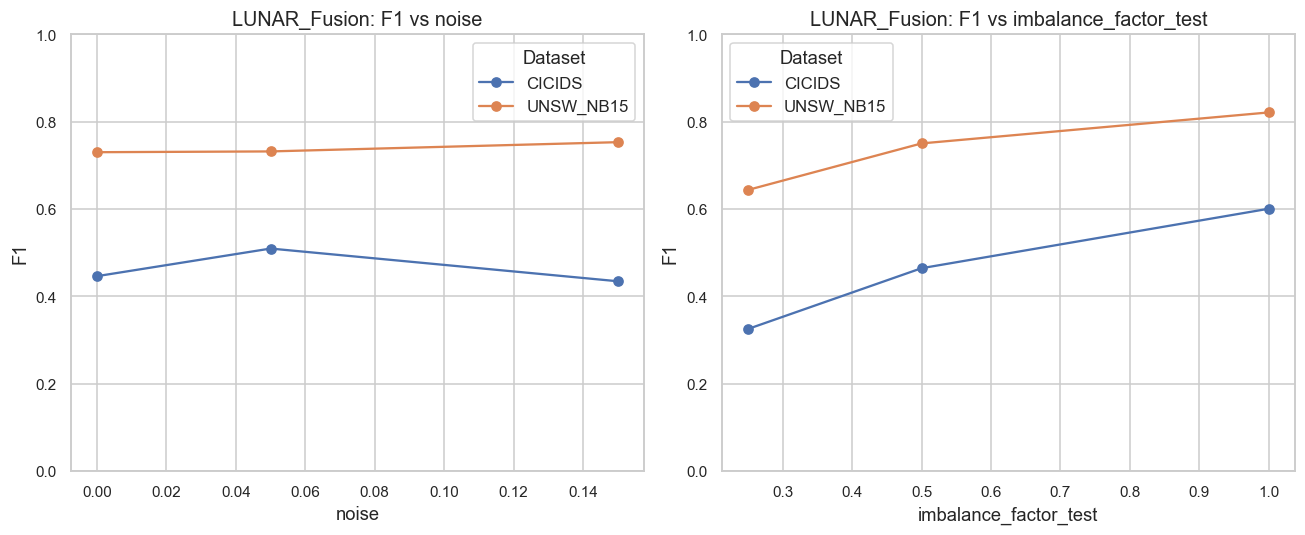

In [19]:
fusion_level_df = df_std[df_std["model_type"] == "Fusion_Level_Comparison"].copy()
fusion_tbl = fusion_level_df[["dataset_name", "fusion_strategy", "AUC_ROC", "AUC_PR",
                               "Precision", "Recall", "F1"]].sort_values(["dataset_name", "fusion_strategy"])
display(fusion_tbl.style.format({c: "{:.3f}" for c in METRIC_COLS})
        .set_caption("Fusion_Level_Comparison — poziomy fuzji"))
fusion_tbl.to_csv(FIG_DIR / "table_3b_fusion_levels.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=fusion_level_df, x="fusion_strategy", y="F1", hue="dataset_name", palette=PALETTE, ax=ax)
ax.set_title("F1 wg poziomu fuzji"); ax.set_ylim(0, 1); ax.tick_params(axis="x", rotation=20); ax.set_xlabel("")
fig.tight_layout()
save_fig(fig, "03b_fusion_levels_bar")
plt.show()

fv2 = df_std[df_std["model_type"] == "LUNAR_Fusion_v2"].copy()
fv2["noise"] = fv2["hyperparameters"].apply(lambda s: get_param(s, "noise"))
fv2["imbalance_factor_test"] = fv2["hyperparameters"].apply(lambda s: get_param(s, "imbalance_factor_test"))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, param in zip(axes, ["noise", "imbalance_factor_test"]):
    curve = fv2.dropna(subset=[param]).groupby(["dataset_name", param])["F1"].mean().reset_index()
    for dset, sub in curve.groupby("dataset_name"):
        sub = sub.sort_values(param)
        ax.plot(sub[param], sub["F1"], marker="o", label=dset)
    ax.set_xlabel(param); ax.set_ylabel("F1"); ax.set_title(f"LUNAR_Fusion: F1 vs {param}")
    ax.set_ylim(0, 1); ax.legend(title="Dataset")
fig.tight_layout()
save_fig(fig, "03c_fusion_sensitivity_curves")
plt.show()

Zapisano: 03d_radar_profile_CICIDS.png , 03d_radar_profile_CICIDS.pdf


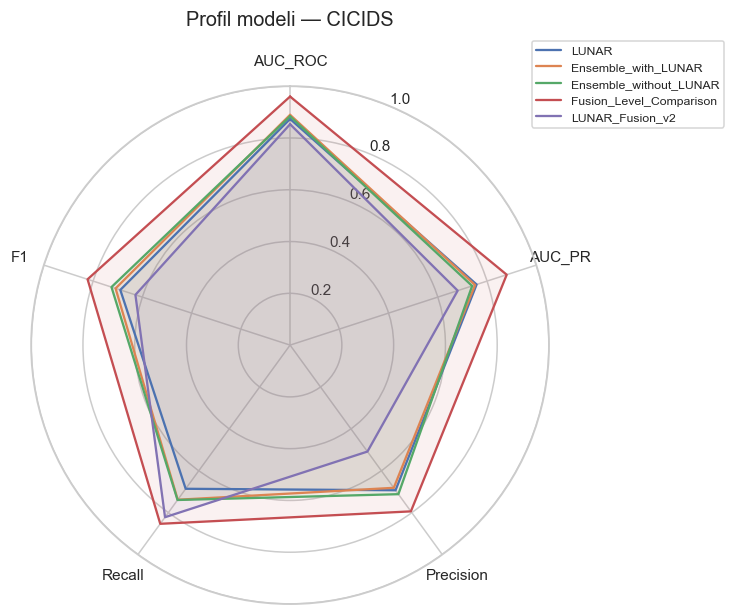

Zapisano: 03d_radar_profile_UNSW_NB15.png , 03d_radar_profile_UNSW_NB15.pdf


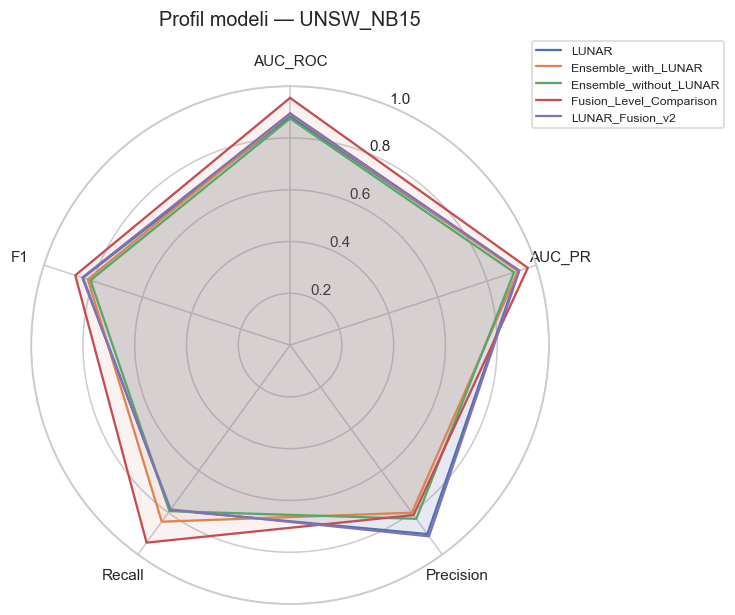

In [ ]:
def radar_chart(data_dict, categories, title, ax):
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories)
    ax.set_ylim(0, 1)
    for label, vals in data_dict.items():
        vals = vals + vals[:1]
        ax.plot(angles, vals, linewidth=1.5, label=label)
        ax.fill(angles, vals, alpha=0.08)
    ax.set_title(title, y=1.1)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)

radar_metrics = ["AUC_ROC", "AUC_PR", "Precision", "Recall", "F1"]
radar_models = ["LUNAR", "Ensemble_with_LUNAR", "Ensemble_without_LUNAR",
                "Fusion_Level_Comparison", "LUNAR_Fusion_v2"]

for dset in df_std["dataset_name"].unique():
    profile = {}
    sub = df_std[df_std["dataset_name"] == dset]
    for m in radar_models:
        cand = sub[sub["model_type"] == m]
        if cand.empty:
            continue
        best = cand.loc[cand["F1"].idxmax()]
        profile[m] = [float(best[c]) for c in radar_metrics]
    if profile:
        fig = plt.figure(figsize=(7, 7))
        ax = plt.subplot(111, polar=True)
        radar_chart(profile, radar_metrics, f"Profil modeli — {dset}", ax)
        fig.tight_layout()
        save_fig(fig, f"03d_radar_profile_{dset}")
        plt.show()

## 4. Robustness

Zapisano: 04a_robustness_curves.png , 04a_robustness_curves.pdf


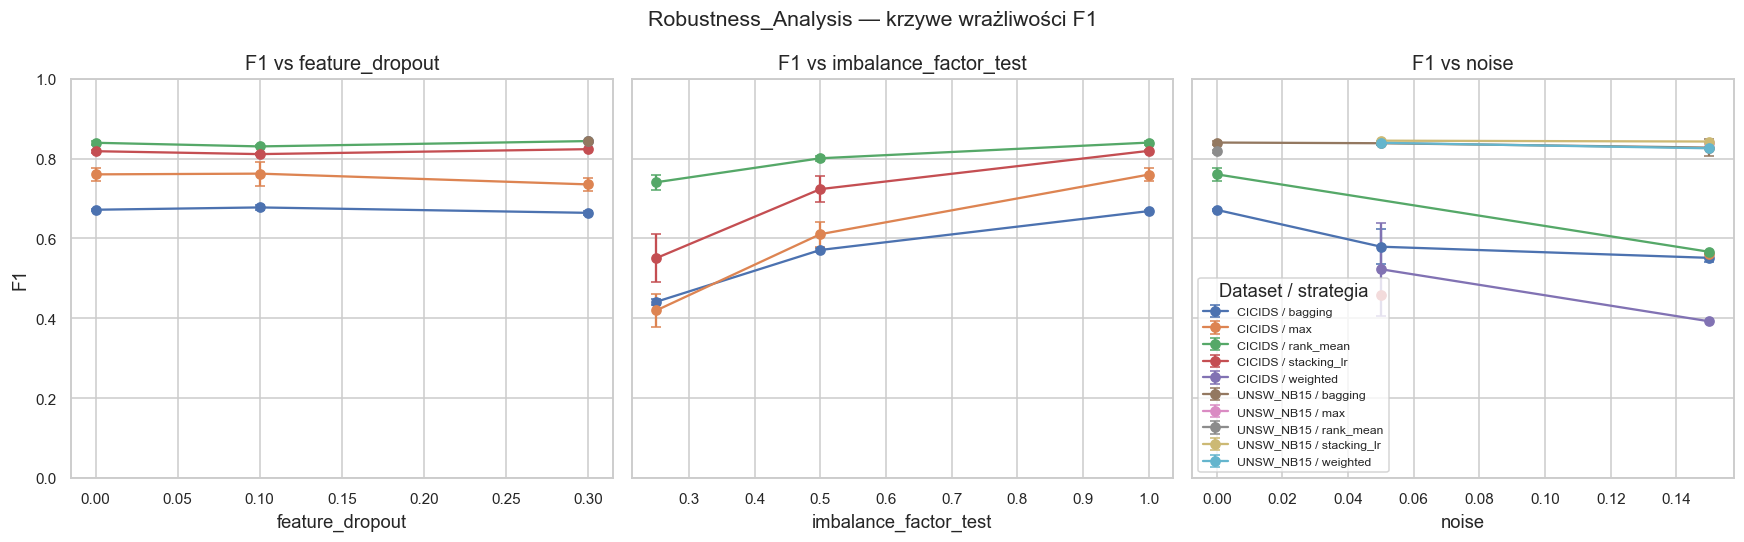

,dataset_name,fusion_strategy,feature_dropout,imbalance_factor_test,noise,AUC_ROC,F1
240,CICIDS,bagging,0.000000,nan,nan,0.866,0.670
246,CICIDS,bagging,0.100000,nan,nan,0.870,0.681
252,CICIDS,bagging,0.300000,nan,nan,0.830,0.667
258,CICIDS,bagging,nan,0.250000,nan,0.869,0.436
264,CICIDS,bagging,nan,0.500000,nan,0.866,0.567
270,CICIDS,bagging,nan,1.000000,nan,0.865,0.669
276,CICIDS,bagging,nan,nan,0.050000,0.854,0.604
282,CICIDS,bagging,nan,nan,0.000000,0.865,0.669
288,CICIDS,bagging,nan,nan,0.150000,0.839,0.542
534,CICIDS,bagging,0.000000,nan,nan,0.859,0.675


In [13]:
rob = df_std[df_std["model_type"] == "Robustness_Analysis"].copy()
rob["feature_dropout"] = rob["hyperparameters"].apply(lambda s: get_param(s, "feature_dropout"))
rob["imbalance_factor_test"] = rob["hyperparameters"].apply(lambda s: get_param(s, "imbalance_factor_test"))
rob["noise"] = rob["hyperparameters"].apply(lambda s: get_param(s, "noise"))

params = ["feature_dropout", "imbalance_factor_test", "noise"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, param in zip(axes, params):
    sub_all = rob.dropna(subset=[param])
    if sub_all.empty:
        ax.set_title(f"{param}: brak danych"); continue
    agg = sub_all.groupby(["dataset_name", "fusion_strategy", param])["F1"].agg(["mean", "std"]).reset_index()
    for (dset, strat), g in agg.groupby(["dataset_name", "fusion_strategy"]):
        g = g.sort_values(param)
        ax.errorbar(g[param], g["mean"], yerr=g["std"], marker="o", capsize=3, label=f"{dset} / {strat}")
    ax.set_xlabel(param); ax.set_title(f"F1 vs {param}"); ax.set_ylim(0, 1)
axes[0].set_ylabel("F1")
axes[-1].legend(title="Dataset / strategia", fontsize=8, loc="lower left")
fig.suptitle("Robustness_Analysis — krzywe wrażliwości F1")
fig.tight_layout()
save_fig(fig, "04a_robustness_curves")
plt.show()

rob_tbl = rob[["dataset_name", "fusion_strategy", "feature_dropout", "imbalance_factor_test",
               "noise", "AUC_ROC", "F1"]].sort_values(["dataset_name", "fusion_strategy"])
display(rob_tbl.style.format({"AUC_ROC": "{:.3f}", "F1": "{:.3f}"}).set_caption("Robustness_Analysis — pełna tabela"))
rob_tbl.to_csv(FIG_DIR / "table_4a_robustness.csv", index=False)

Zapisano: 04b_robustness_index_bar.png , 04b_robustness_index_bar.pdf


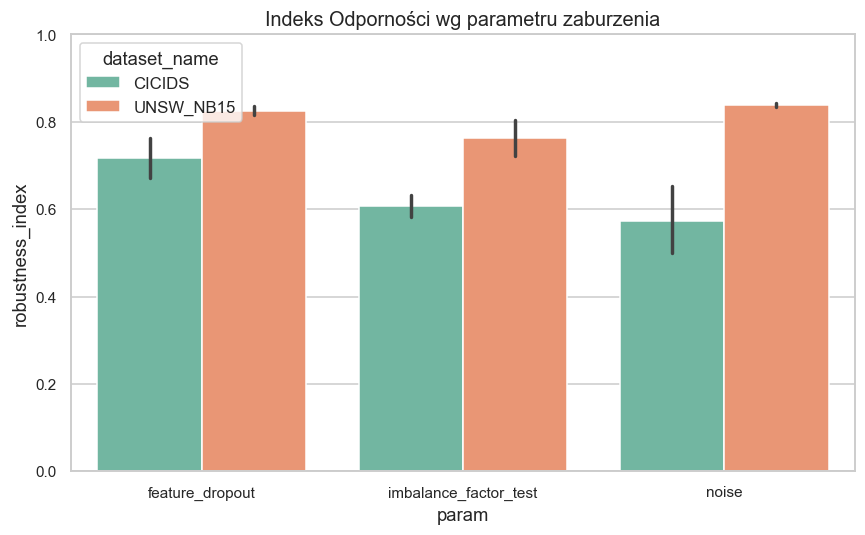

In [ ]:
robustness_rows = []
for param in params:
    sub_all = rob.dropna(subset=[param])
    if sub_all.empty:
        continue
    for (dset, strat), g in sub_all.groupby(["dataset_name", "fusion_strategy"]):
        g = g.sort_values(param)
        if g[param].nunique() < 2:
            continue
        x, y = g[param].values, g["F1"].values
        area = np.trapezoid(y, x)
        area_norm = area / (x.max() - x.min())
        robustness_rows.append({"dataset_name": dset, "fusion_strategy": strat,
                                 "param": param, "robustness_index": area_norm})

rob_idx = pd.DataFrame(robustness_rows)
if not rob_idx.empty:
    display(rob_idx.pivot_table(index=["dataset_name", "fusion_strategy"], columns="param",
                                 values="robustness_index")
            .style.format("{:.3f}")
            .set_caption("Zagregowany Indeks Odporności (średnie F1 pod krzywą degradacji, 0-1, wyżej=lepiej)"))
    rob_idx.to_csv(FIG_DIR / "table_4b_robustness_index.csv", index=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=rob_idx, x="param", y="robustness_index", hue="dataset_name", palette=PALETTE, ax=ax)
    ax.set_ylim(0, 1)
    ax.set_title("Indeks Odporności wg parametru zaburzenia")
    fig.tight_layout()
    save_fig(fig, "04b_robustness_index_bar")
    plt.show()
else:
    print("Za mało punktów (>=2 wartości parametru) do wyliczenia indeksu odporności.")

## 5. Obliczenia i Złożoność

Zapisano: 05a_f1_vs_runtime_tradeoff.png , 05a_f1_vs_runtime_tradeoff.pdf


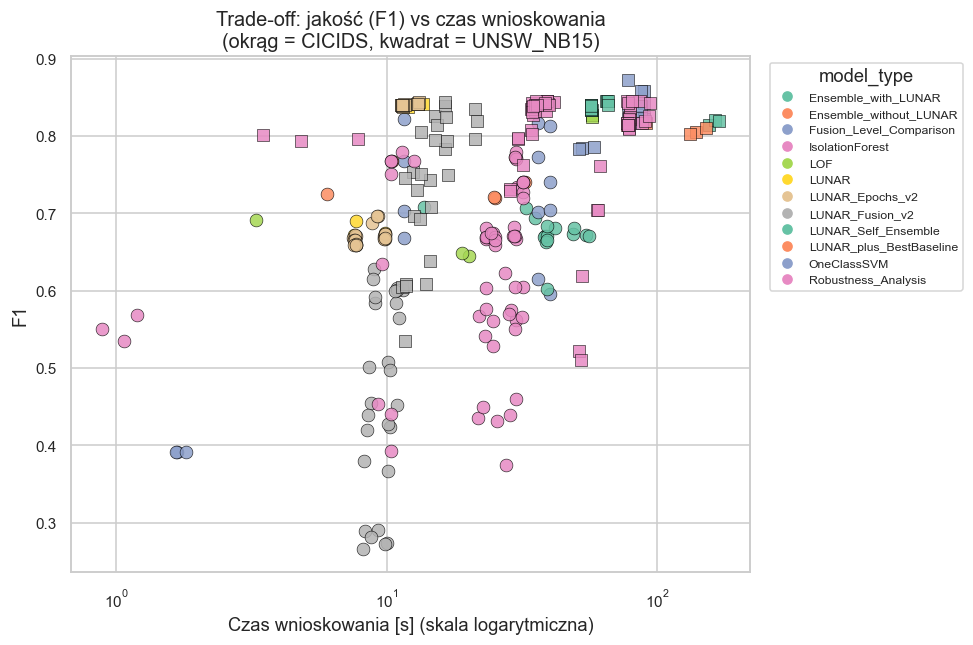

,dataset_name,model_type,fusion_strategy,F1,AUC_ROC,runtime_train,runtime_inference
621,UNSW_NB15,Fusion_Level_Comparison,lunar_self_ensemble,0.840,0.887,0.0,0.00
618,CICIDS,Fusion_Level_Comparison,lunar_self_ensemble,0.681,0.792,0.0,0.00
324,CICIDS,Fusion_Level_Comparison,lunar_self_ensemble,0.684,0.799,0.0,0.00
327,UNSW_NB15,Fusion_Level_Comparison,lunar_self_ensemble,0.835,0.850,0.0,0.00
33,UNSW_NB15,Fusion_Level_Comparison,lunar_self_ensemble,0.845,0.884,0.0,0.00
30,CICIDS,Fusion_Level_Comparison,lunar_self_ensemble,0.681,0.792,0.0,0.00
630,CICIDS,IsolationForest,none,0.550,0.817,0.5,0.88
336,CICIDS,IsolationForest,none,0.535,0.811,0.5,1.07
42,CICIDS,IsolationForest,none,0.568,0.829,0.6,1.19
478,CICIDS,OneClassSVM,none,0.391,0.768,0.8,1.66


In [15]:
comp_df = df_std.copy()
fig, ax = plt.subplots(figsize=(9, 6))
markers = {"CICIDS": "o", "UNSW_NB15": "s"}
model_types_sorted = sorted(comp_df["model_type"].unique())
palette_map = dict(zip(model_types_sorted, sns.color_palette(PALETTE, len(model_types_sorted))))

for (mtype, dset), g in comp_df.groupby(["model_type", "dataset_name"]):
    ax.scatter(g["runtime_inference"], g["F1"], color=palette_map[mtype],
               marker=markers.get(dset, "x"), s=70, alpha=0.85, edgecolor="black", linewidth=0.4)

ax.set_xscale("log")
ax.set_xlabel("Czas wnioskowania [s] (skala logarytmiczna)")
ax.set_ylabel("F1")
ax.set_title("Trade-off: jakość (F1) vs czas wnioskowania\n(okrąg = CICIDS, kwadrat = UNSW_NB15)")

handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=8, label=m)
           for m, c in palette_map.items()]
ax.legend(handles=handles, title="model_type", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
save_fig(fig, "05a_f1_vs_runtime_tradeoff")
plt.show()

comp_tbl = comp_df[["dataset_name", "model_type", "fusion_strategy", "F1", "AUC_ROC",
                     "runtime_train", "runtime_inference"]].sort_values("runtime_inference")
display(comp_tbl.style.format({"F1": "{:.3f}", "AUC_ROC": "{:.3f}",
                                "runtime_train": "{:.1f}", "runtime_inference": "{:.2f}"})
        .set_caption("Czas treningu/wnioskowania vs jakość"))
comp_tbl.to_csv(FIG_DIR / "table_5_complexity.csv", index=False)

## 6. Podsumowanie

,dataset_name,family,model_type,fusion_strategy,AUC_ROC,AUC_PR,Precision,Recall,F1,runtime_train,runtime_inference
7,CICIDS,Fusion (best level),Fusion_Level_Comparison,feature_level,0.960,0.880,0.794,0.853,0.822,254.2,11.63
10,CICIDS,Robustness (best cfg),Robustness_Analysis,rank_mean,0.900,0.737,0.724,0.844,0.779,180.3,30.19
9,CICIDS,LUNAR+BestBaseline,LUNAR_plus_BestBaseline,rank_mean,0.892,0.672,0.721,0.832,0.772,181.7,29.96
5,CICIDS,Ensemble -LUNAR,Ensemble_without_LUNAR,rank_mean,0.884,0.739,0.712,0.740,0.725,4.8,6.04
4,CICIDS,Ensemble +LUNAR,Ensemble_with_LUNAR,rank_mean,0.889,0.751,0.681,0.738,0.709,217.4,13.73
1,CICIDS,LOF (baseline),LOF,none,0.857,0.575,0.586,0.845,0.692,1.6,3.28
0,CICIDS,LUNAR (solo),LUNAR,none,0.874,0.758,0.693,0.686,0.690,165.4,7.71
6,CICIDS,LUNAR Self-Ensemble,LUNAR_Self_Ensemble,voting,0.799,0.558,0.687,0.681,0.684,886.1,39.04
8,CICIDS,Fusion v2 (robust),LUNAR_Fusion_v2,rank_mean,0.853,0.681,0.508,0.822,0.628,213.9,9.01
2,CICIDS,IsolationForest (baseline),IsolationForest,none,0.829,0.615,0.481,0.695,0.568,0.6,1.19


Zapisano: 06a_final_comparison.png , 06a_final_comparison.pdf


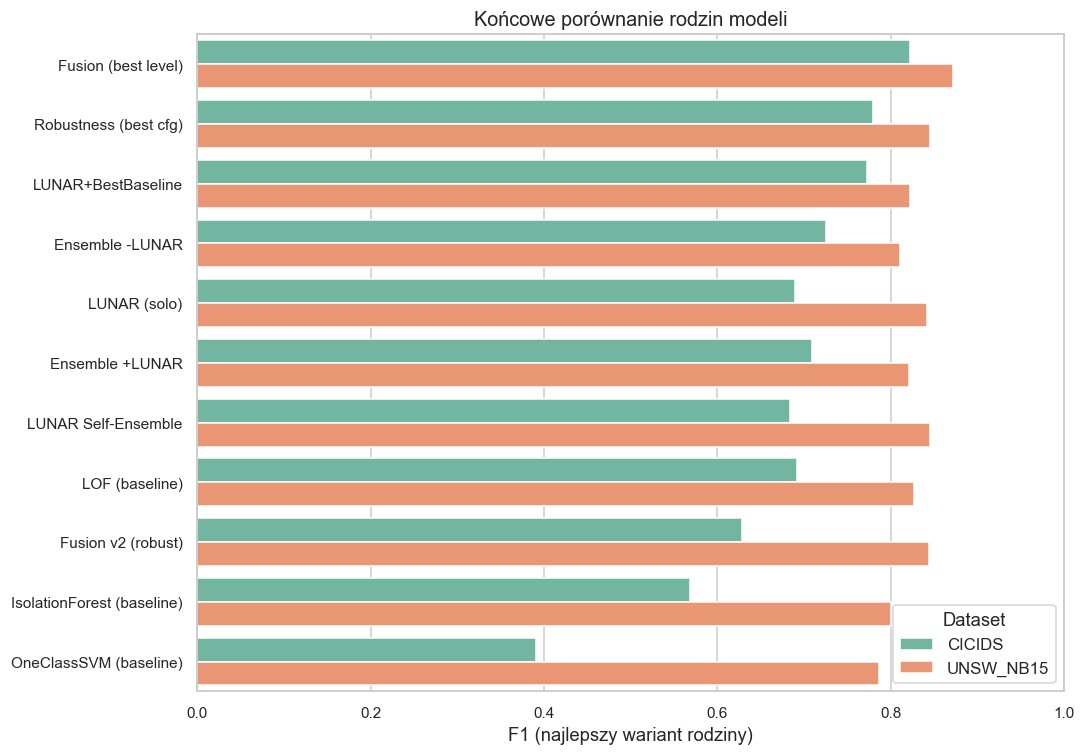

In [16]:
family_map = {
    "LUNAR": "LUNAR (solo)", "LOF": "LOF (baseline)", "IsolationForest": "IsolationForest (baseline)",
    "OneClassSVM": "OneClassSVM (baseline)", "Ensemble_with_LUNAR": "Ensemble +LUNAR",
    "Ensemble_without_LUNAR": "Ensemble -LUNAR", "LUNAR_Self_Ensemble": "LUNAR Self-Ensemble",
    "Fusion_Level_Comparison": "Fusion (best level)", "LUNAR_Fusion_v2": "Fusion v2 (robust)",
    "LUNAR_plus_BestBaseline": "LUNAR+BestBaseline", "Robustness_Analysis": "Robustness (best cfg)",
}

best_rows = []
for dset, sub in df_std.groupby("dataset_name"):
    for model_type, label in family_map.items():
        cand = sub[sub["model_type"] == model_type]
        if cand.empty:
            continue
        best = cand.loc[cand["F1"].idxmax()]
        best_rows.append({
            "dataset_name": dset, "family": label, "model_type": model_type,
            "fusion_strategy": best.get("fusion_strategy", np.nan),
            "AUC_ROC": best["AUC_ROC"], "AUC_PR": best["AUC_PR"],
            "Precision": best["Precision"], "Recall": best["Recall"], "F1": best["F1"],
            "runtime_train": best["runtime_train"], "runtime_inference": best["runtime_inference"],
        })

final_tbl = pd.DataFrame(best_rows).sort_values(["dataset_name", "F1"], ascending=[True, False])
display(final_tbl.style.format({c: "{:.3f}" for c in METRIC_COLS} |
                                {"runtime_train": "{:.1f}", "runtime_inference": "{:.2f}"})
        .set_caption("Najlepszy wariant z każdej rodziny modeli (wg F1) — z czasami"))
final_tbl.to_csv(FIG_DIR / "table_6_final_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 7))
order = final_tbl.groupby("family")["F1"].mean().sort_values(ascending=False).index
sns.barplot(data=final_tbl, y="family", x="F1", hue="dataset_name", order=order, palette=PALETTE, ax=ax)
ax.set_xlim(0, 1); ax.set_xlabel("F1 (najlepszy wariant rodziny)"); ax.set_ylabel("")
ax.set_title("Końcowe porównanie rodzin modeli")
ax.legend(title="Dataset")
fig.tight_layout()
save_fig(fig, "06a_final_comparison")
plt.show()

In [ ]:
latex_cols = ["dataset_name", "family", "AUC_ROC", "F1", "Precision", "Recall",
              "runtime_train", "runtime_inference"]
final_tbl_export = final_tbl[latex_cols].rename(columns={
    "dataset_name": "Dataset", "family": "Model", "runtime_train": "T_train [s]", "runtime_inference": "T_infer [s]"
})

latex_path = FIG_DIR / "table_6_final_comparison.tex"
with open(latex_path, "w", encoding="utf-8") as f:
    f.write(final_tbl_export.to_latex(
        index=False, float_format="%.3f", escape=True,
        caption="Zestawienie najlepszych wariantów modeli wg F1 (próg standardowy).",
        label="tab:final_comparison"
    ))
print(f"Zapisano tabelę LaTeX: {latex_path}")
print()
print(final_tbl_export.to_latex(index=False, float_format='%.3f'))

Zapisano tabelę LaTeX: ..\results\aggregation\notebook_figs\table_6_final_comparison.tex

\begin{tabular}{llrrrrrr}
\toprule
Dataset & Model & AUC_ROC & F1 & Precision & Recall & T_train [s] & T_infer [s] \\
\midrule
CICIDS & Fusion (best level) & 0.960 & 0.822 & 0.794 & 0.853 & 254.200 & 11.628 \\
CICIDS & Robustness (best cfg) & 0.900 & 0.779 & 0.724 & 0.844 & 180.319 & 30.188 \\
CICIDS & LUNAR+BestBaseline & 0.892 & 0.772 & 0.721 & 0.832 & 181.732 & 29.959 \\
CICIDS & Ensemble -LUNAR & 0.884 & 0.725 & 0.712 & 0.740 & 4.850 & 6.039 \\
CICIDS & Ensemble +LUNAR & 0.889 & 0.709 & 0.681 & 0.738 & 217.366 & 13.727 \\
CICIDS & LOF (baseline) & 0.857 & 0.692 & 0.586 & 0.845 & 1.645 & 3.281 \\
CICIDS & LUNAR (solo) & 0.874 & 0.690 & 0.693 & 0.686 & 165.364 & 7.711 \\
CICIDS & LUNAR Self-Ensemble & 0.799 & 0.684 & 0.687 & 0.681 & 886.128 & 39.044 \\
CICIDS & Fusion v2 (robust) & 0.853 & 0.628 & 0.508 & 0.822 & 213.916 & 9.005 \\
CICIDS & IsolationForest (baseline) & 0.829 & 0.568 & 0.481 & 0.